In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 4

Using device: cuda


/tmp/ipykernel_57/1047253242.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()   # 🔥 AMP
  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/1047253242.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # 🔥 mixed precision
100%|██████████| 31/31 [00:12<00:00,  2.54it/s]
/tmp/ipykernel_57/1047253242.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: Loss=1.9247, Val Acc=43.48%


100%|██████████| 31/31 [00:09<00:00,  3.44it/s]


Epoch 2: Loss=0.9962, Val Acc=58.10%


...

Epoch 8: Loss=0.3945, Val Acc=88.14%


100%|██████████| 31/31 [00:08<00:00,  3.65it/s]


Epoch 9: Loss=0.3701, Val Acc=86.56%


100%|██████████| 31/31 [00:08<00:00,  3.58it/s]


Epoch 10: Loss=0.3606, Val Acc=90.51%
Test Accuracy: 88.67924528301887


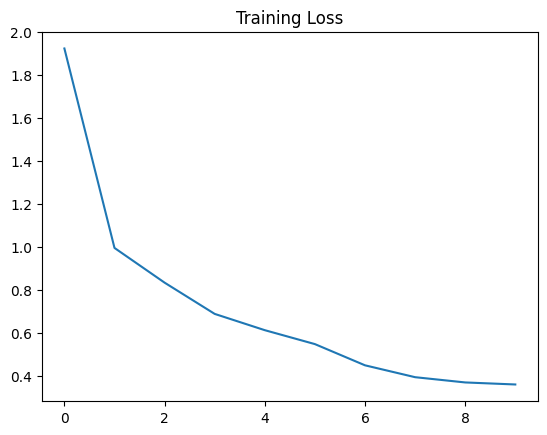

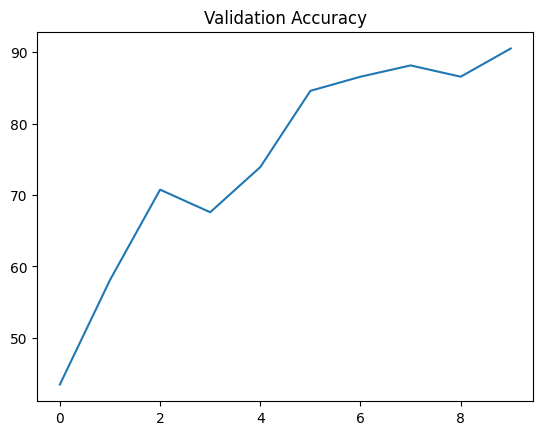

In [1]:
# =========================
# CUSTOM CNN - GPU OPTIMIZED
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---- CONFIG ----
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 10
NUM_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- TRANSFORMS ----
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ---- DATA ----
train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=train_transform)
val_data   = datasets.ImageFolder(f"{DATA_PATH}/val", transform=val_transform)
test_data  = datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE,
                          num_workers=2, pin_memory=True)

# ---- MODEL ----
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = CustomCNN().to(device)

# ---- TRAIN SETUP ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()   # 🔥 AMP

train_losses, val_accs = [], []

# ---- EVAL ----
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                out = model(x)

            preds = out.argmax(dim=1)
            total += y.size(0)
            correct += (preds == y).sum().item()

    return 100 * correct / total

# ---- TRAIN LOOP ----
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for x, y in tqdm(train_loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():  # 🔥 mixed precision
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    loss_epoch = running_loss / len(train_loader)
    val_acc = evaluate(model, val_loader)

    train_losses.append(loss_epoch)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={loss_epoch:.4f}, Val Acc={val_acc:.2f}%")

# ---- TEST ----
print("Test Accuracy:", evaluate(model, test_loader))

# ---- PLOTS ----
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

plt.figure()
plt.plot(val_accs)
plt.title("Validation Accuracy")
plt.show()

torch.save(model.state_dict(), "custom_cnn_gpu.pth")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 159MB/s]  
/tmp/ipykernel_57/2994527152.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/61 [00:00<?, ?it/s]/tmp/ipykernel_57/2994527152.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 61/61 [00:10<00:00,  5.68it/s]
/tmp/ipykernel_57/2994527152.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: Loss=0.9340, Val Acc=85.38%


...

Epoch 3: Loss=0.4045, Val Acc=90.12%


100%|██████████| 61/61 [00:10<00:00,  5.96it/s]


Epoch 4: Loss=0.3544, Val Acc=92.49%


100%|██████████| 61/61 [00:09<00:00,  6.12it/s]


Epoch 5: Loss=0.3060, Val Acc=92.89%
Test Accuracy: 91.50943396226415


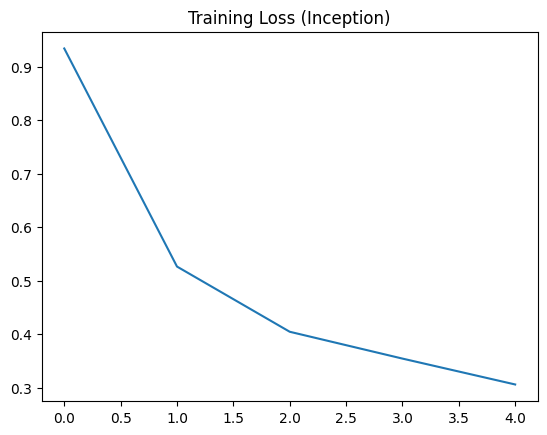

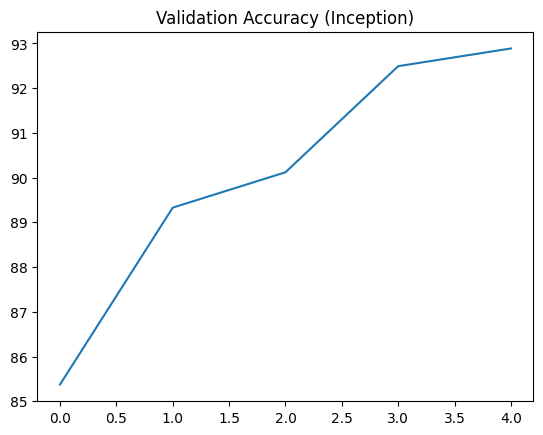

In [2]:
# =========================
# INCEPTION V3 - GPU OPTIMIZED
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---- CONFIG ----
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"
IMG_SIZE = 299
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- TRANSFORMS ----
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ---- DATA ----
train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=train_transform)
val_data   = datasets.ImageFolder(f"{DATA_PATH}/val", transform=val_transform)
test_data  = datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE,
                          num_workers=2, pin_memory=True)

# ---- MODEL ----
model = models.inception_v3(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.aux_logits = False

model = model.to(device)

# ---- TRAIN SETUP ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

train_losses, val_accs = [], []

# ---- EVAL ----
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                out = model(x)

            preds = out.argmax(dim=1)
            total += y.size(0)
            correct += (preds == y).sum().item()

    return 100 * correct / total

# ---- TRAIN ----
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for x, y in tqdm(train_loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    loss_epoch = running_loss / len(train_loader)
    val_acc = evaluate(model, val_loader)

    train_losses.append(loss_epoch)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={loss_epoch:.4f}, Val Acc={val_acc:.2f}%")

# ---- TEST ----
print("Test Accuracy:", evaluate(model, test_loader))

# ---- PLOTS ----
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss (Inception)")
plt.show()

plt.figure()
plt.plot(val_accs)
plt.title("Validation Accuracy (Inception)")
plt.show()

torch.save(model.state_dict(), "inception_v3_gpu.pth")

/tmp/ipykernel_57/924244195.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/924244195.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 31/31 [00:12<00:00,  2.41it/s]
/tmp/ipykernel_57/924244195.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: TrainAcc=41.52 ValAcc=50.59 F1=0.419


  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/924244195.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 31/31 [00:08<00:00,  3.62it/s]
/tmp/ipykernel_57/924244195.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2: TrainAcc=58.12 ValAcc=59.68 F1=0.591


  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/924244195.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 31/31 [00:08<00:00,  3.68it/s]
/tmp/ipykernel_57/924244195.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 9: TrainAcc=85.44 ValAcc=90.51 F1=0.908


  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/924244195.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 31/31 [00:08<00:00,  3.73it/s]
/tmp/ipykernel_57/924244195.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10: TrainAcc=87.39 ValAcc=90.91 F1=0.907


/tmp/ipykernel_57/924244195.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Test Accuracy: 91.50943396226415
Test F1 Score: 0.9153214958299705


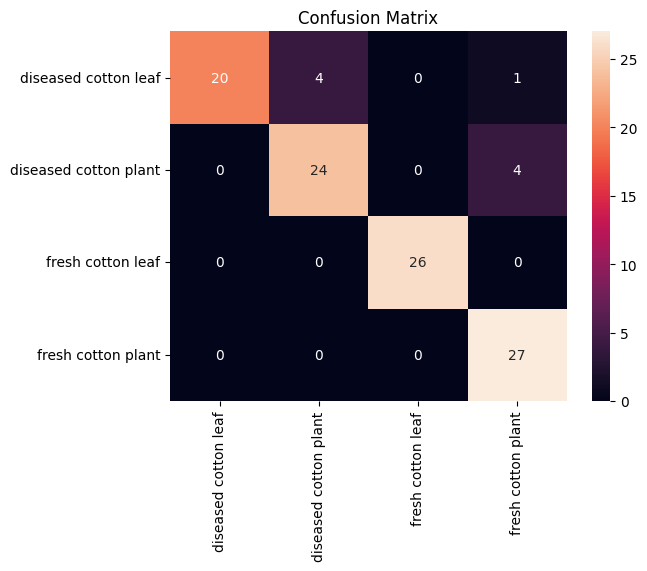

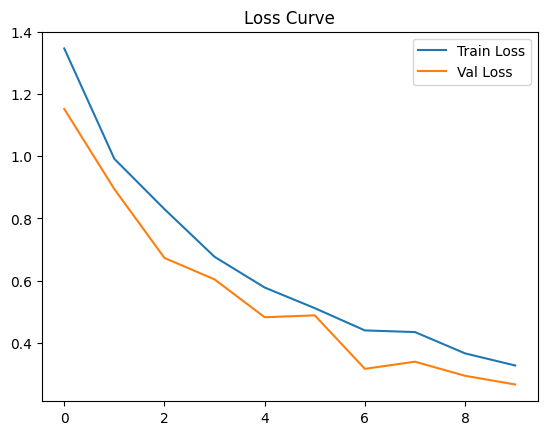

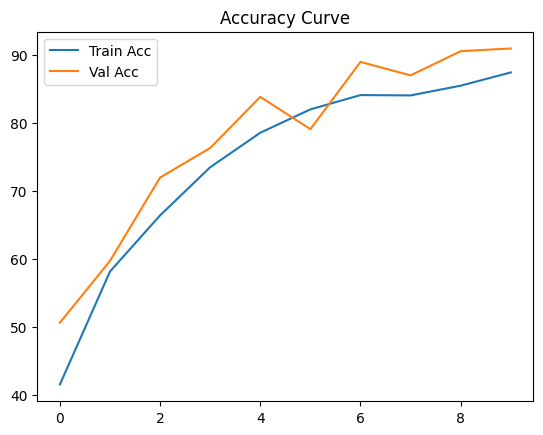

In [1]:
# =========================
# CUSTOM CNN - FINAL VERSION
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import numpy as np

# ---- CONFIG ----
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 10
NUM_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- TRANSFORMS ----
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ---- DATA ----
train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=train_transform)
val_data   = datasets.ImageFolder(f"{DATA_PATH}/val", transform=val_transform)
test_data  = datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

class_names = train_data.classes

# ---- MODEL ----
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,NUM_CLASSES)
        )
    def forward(self,x):
        return self.fc(self.conv(x))

model = CustomCNN().to(device)

# ---- TRAIN SETUP ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# ---- EVAL ----
def evaluate_full(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    loss_total = 0

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = criterion(out,y)

            loss_total += loss.item()
            preds = out.argmax(dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    acc = (np.array(preds_all) == np.array(labels_all)).mean()*100
    f1 = f1_score(labels_all, preds_all, average="macro")

    return loss_total/len(loader), acc, f1, preds_all, labels_all

# ---- TRAIN LOOP ----
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct, total = 0,0

    for x,y in tqdm(train_loader):
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = out.argmax(dim=1)
        correct += (preds==y).sum().item()
        total += y.size(0)

    train_loss = running_loss/len(train_loader)
    train_acc = 100*correct/total

    val_loss, val_acc, val_f1, _, _ = evaluate_full(model,val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f} F1={val_f1:.3f}")

# ---- TEST METRICS ----
test_loss, test_acc, test_f1, preds, labels = evaluate_full(model,test_loader)

print("\nTest Accuracy:", test_acc)
print("Test F1 Score:", test_f1)

# ---- CONFUSION MATRIX ----
cm = confusion_matrix(labels, preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

# ---- PLOTS ----
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# ---- SAVE ----
torch.save(model.state_dict(), "/kaggle/working/custom_cnn.pth")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 230MB/s] 
/tmp/ipykernel_57/3431963117.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/61 [00:00<?, ?it/s]/tmp/ipykernel_57/3431963117.py:103: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 61/61 [00:09<00:00,  6.21it/s]
/tmp/ipykernel_57/3431963117.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: TrainAcc=68.38 ValAcc=86.17 F1=0.847


  0%|          | 0/61 [00:00<?, ?it/s]/tmp/ipykernel_57/3431963117.py:103: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 61/61 [00:09<00:00,  6.49it/s]
/tmp/ipykernel_57/3431963117.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 4: TrainAcc=89.39 ValAcc=91.70 F1=0.907


  0%|          | 0/61 [00:00<?, ?it/s]/tmp/ipykernel_57/3431963117.py:103: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 61/61 [00:09<00:00,  6.22it/s]
/tmp/ipykernel_57/3431963117.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 5: TrainAcc=90.83 ValAcc=94.07 F1=0.935


/tmp/ipykernel_57/3431963117.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Test Accuracy: 91.50943396226415
Test F1 Score: 0.9151565798733287


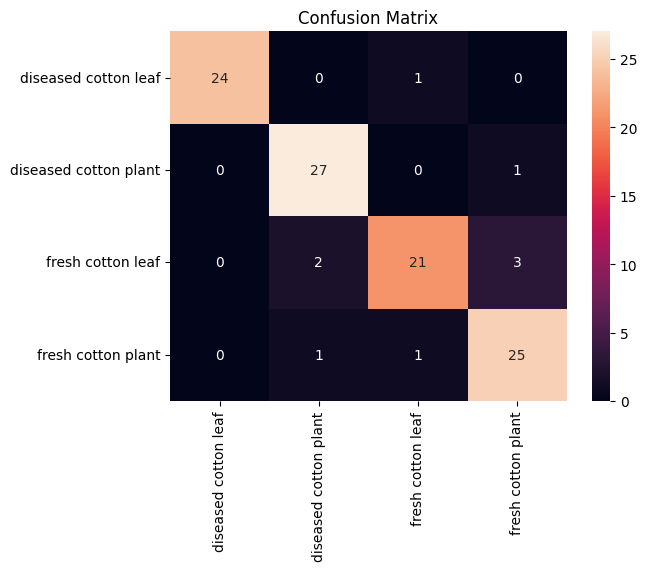

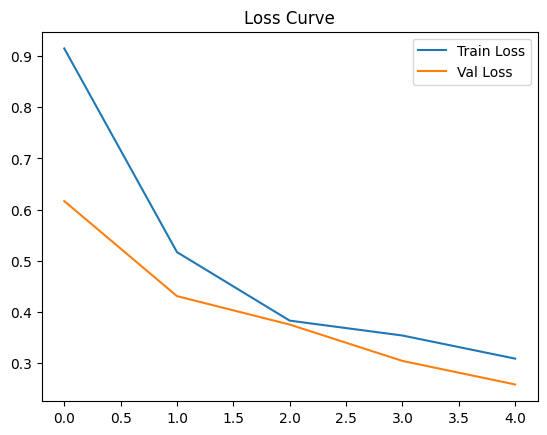

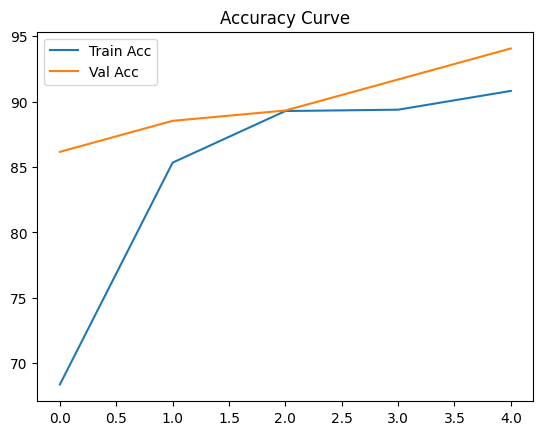

In [2]:
# =========================
# INCEPTION V3 - FINAL VERSION
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import numpy as np

# ---- CONFIG ----
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"
IMG_SIZE = 299
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- TRANSFORMS ----
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ---- DATA ----
train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=train_transform)
val_data   = datasets.ImageFolder(f"{DATA_PATH}/val", transform=val_transform)
test_data  = datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

class_names = train_data.classes

# ---- MODEL ----
model = models.inception_v3(pretrained=True)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.aux_logits = False

model = model.to(device)

# ---- TRAIN SETUP ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# ---- EVAL ----
def evaluate_full(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    loss_total = 0

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = criterion(out,y)

            loss_total += loss.item()
            preds = out.argmax(dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    acc = (np.array(preds_all)==np.array(labels_all)).mean()*100
    f1 = f1_score(labels_all, preds_all, average="macro")

    return loss_total/len(loader), acc, f1, preds_all, labels_all

# ---- TRAIN ----
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct,total = 0,0

    for x,y in tqdm(train_loader):
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = out.argmax(dim=1)
        correct += (preds==y).sum().item()
        total += y.size(0)

    train_loss = running_loss/len(train_loader)
    train_acc = 100*correct/total

    val_loss, val_acc, val_f1, _, _ = evaluate_full(model,val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f} F1={val_f1:.3f}")

# ---- TEST ----
test_loss, test_acc, test_f1, preds, labels = evaluate_full(model,test_loader)

print("\nTest Accuracy:", test_acc)
print("Test F1 Score:", test_f1)

# ---- CONFUSION MATRIX ----
cm = confusion_matrix(labels, preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

# ---- PLOTS ----
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# ---- SAVE ----
torch.save(model.state_dict(), "/kaggle/working/inception_v3.pth")

Using device: cuda


/tmp/ipykernel_57/1363952834.py:76: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/1363952834.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 31/31 [00:08<00:00,  3.76it/s]
/tmp/ipykernel_57/1363952834.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: Loss=1.4749, Val Acc=48.22%, F1=0.426, AUC=0.791


  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/1363952834.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 31/31 [00:08<00:00,  3.80it/s]
/tmp/ipykernel_57/1363952834.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2: Loss=1.0135, Val Acc=56.92%, F1=0.498, AUC=0.868


...

  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/1363952834.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 31/31 [00:07<00:00,  3.90it/s]
/tmp/ipykernel_57/1363952834.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9: Loss=0.4055, Val Acc=86.96%, F1=0.870, AUC=0.982


  0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_57/1363952834.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 31/31 [00:08<00:00,  3.73it/s]
/tmp/ipykernel_57/1363952834.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10: Loss=0.3389, Val Acc=91.30%, F1=0.908, AUC=0.990

Final Results:
Test Accuracy: 89.6226
Macro F1: 0.8933
Macro AUC: 0.9870
Best Val Accuracy: 91.3043


/tmp/ipykernel_57/1363952834.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


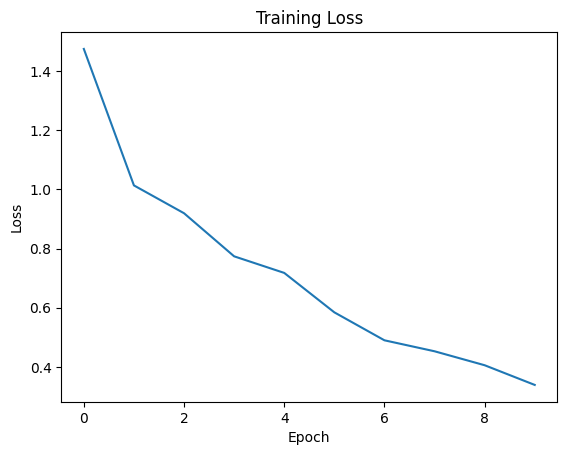

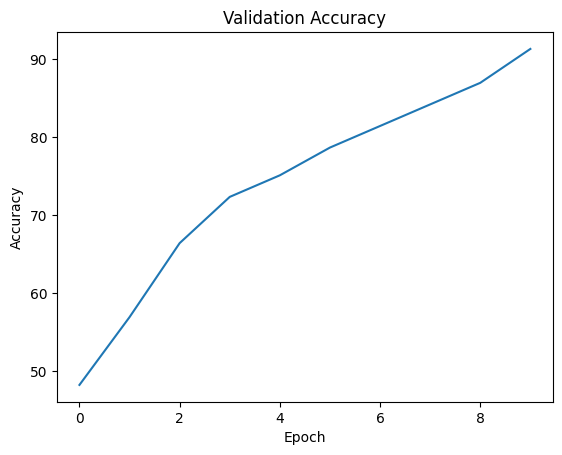

In [2]:
# =========================
# CUSTOM CNN - FINAL (GPU + ALL METRICS FIXED)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# ---- CONFIG ----
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 10
NUM_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- TRANSFORMS ----
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ---- DATA ----
train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=train_transform)
val_data   = datasets.ImageFolder(f"{DATA_PATH}/val", transform=val_transform)
test_data  = datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE,
                          num_workers=2, pin_memory=True)

# ---- MODEL ----
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = CustomCNN().to(device)

# ---- TRAIN SETUP ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

train_losses, val_accs = [], []
best_val_acc = 0

# ---- FULL EVALUATION ----
def evaluate_full(model, loader):
    model.eval()
    correct, total = 0, 0

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                out = model(x)

            probs = torch.softmax(out, dim=1)
            preds = out.argmax(dim=1)

            total += y.size(0)
            correct += (preds == y).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average="macro")

    # ---- FIXED AUC ----
    labels_np = np.array(all_labels)
    probs_np = np.array(all_probs)

    labels_bin = label_binarize(labels_np, classes=list(range(NUM_CLASSES)))
    auc = roc_auc_score(labels_bin, probs_np, average="macro", multi_class="ovr")

    return acc, f1, auc

# ---- TRAIN LOOP ----
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for x, y in tqdm(train_loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    loss_epoch = running_loss / len(train_loader)

    val_acc, val_f1, val_auc = evaluate_full(model, val_loader)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

    train_losses.append(loss_epoch)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={loss_epoch:.4f}, Val Acc={val_acc:.2f}%, F1={val_f1:.3f}, AUC={val_auc:.3f}")

# ---- FINAL TEST ----
test_acc, test_f1, test_auc = evaluate_full(model, test_loader)

print("\nFinal Results:")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")
print(f"Macro AUC: {test_auc:.4f}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")

# ---- PLOTS ----
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(val_accs)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# ---- SAVE MODEL ----
torch.save(model.state_dict(), "/kaggle/working/custom_cnn_gpu.pth")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 197MB/s] 
/tmp/ipykernel_57/2186908678.py:63: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/61 [00:00<?, ?it/s]/tmp/ipykernel_57/2186908678.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 61/61 [00:09<00:00,  6.32it/s]
/tmp/ipykernel_57/2186908678.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: TrainAcc=65.15 ValAcc=88.54 F1=0.868 AUC=0.985


  0%|          | 0/61 [00:00<?, ?it/s]/tmp/ipykernel_57/2186908678.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 61/61 [00:09<00:00,  6.45it/s]
/tmp/ipykernel_57/2186908678.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 4: TrainAcc=89.24 ValAcc=93.68 F1=0.929 AUC=0.995


  0%|          | 0/61 [00:00<?, ?it/s]/tmp/ipykernel_57/2186908678.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 61/61 [00:09<00:00,  6.52it/s]
/tmp/ipykernel_57/2186908678.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 5: TrainAcc=90.42 ValAcc=93.28 F1=0.923 AUC=0.995


/tmp/ipykernel_57/2186908678.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Final Results:
Test Accuracy: 91.5094
Macro F1: 0.9142
Macro AUC: 0.9895
Best Val Accuracy: 93.6759


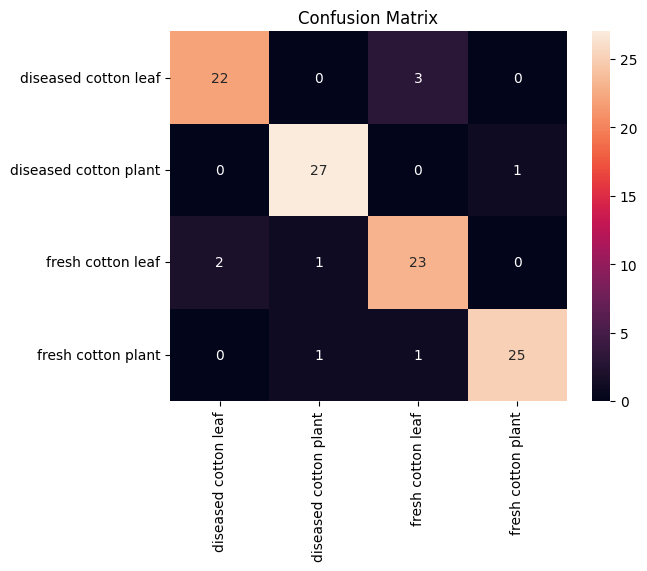

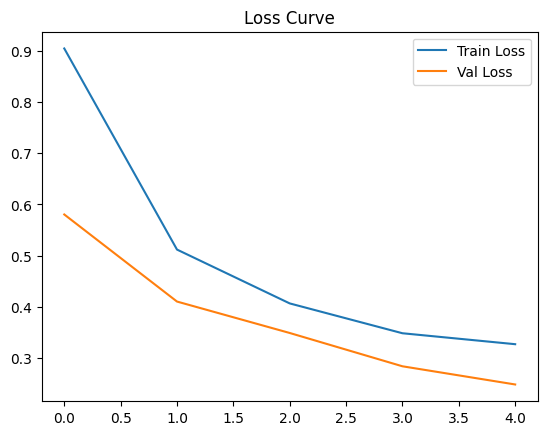

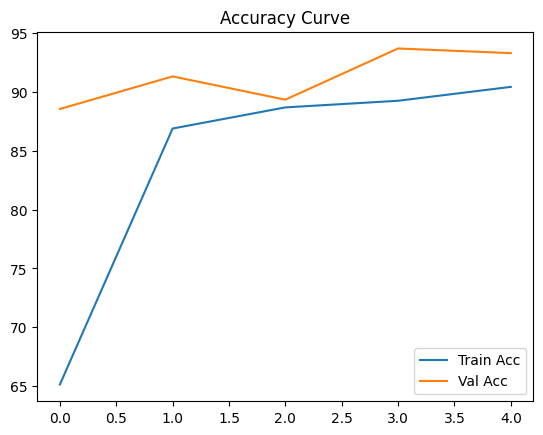

In [3]:
# =========================
# INCEPTION V3 - FINAL (GPU + ALL METRICS)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np

# ---- CONFIG ----
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"
IMG_SIZE = 299
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- TRANSFORMS ----
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ---- DATA ----
train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=train_transform)
val_data   = datasets.ImageFolder(f"{DATA_PATH}/val", transform=val_transform)
test_data  = datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

class_names = train_data.classes

# ---- MODEL ----
model = models.inception_v3(pretrained=True)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.aux_logits = False

model = model.to(device)

# ---- TRAIN SETUP ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

# ---- EVAL (FULL METRICS) ----
def evaluate_full(model, loader):
    model.eval()
    preds_all, labels_all, probs_all = [], [], []
    loss_total = 0

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = criterion(out,y)

            probs = torch.softmax(out, dim=1)
            preds = out.argmax(dim=1)

            loss_total += loss.item()

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())

    acc = (np.array(preds_all)==np.array(labels_all)).mean()*100
    f1 = f1_score(labels_all, preds_all, average="macro")

    # ---- FIXED AUC ----
    labels_np = np.array(labels_all)
    probs_np = np.array(probs_all)

    labels_bin = label_binarize(labels_np, classes=list(range(NUM_CLASSES)))
    auc = roc_auc_score(labels_bin, probs_np, average="macro", multi_class="ovr")

    return loss_total/len(loader), acc, f1, auc, preds_all, labels_all

# ---- TRAIN ----
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct,total = 0,0

    for x,y in tqdm(train_loader):
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = out.argmax(dim=1)
        correct += (preds==y).sum().item()
        total += y.size(0)

    train_loss = running_loss/len(train_loader)
    train_acc = 100*correct/total

    val_loss, val_acc, val_f1, val_auc, _, _ = evaluate_full(model,val_loader)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f} F1={val_f1:.3f} AUC={val_auc:.3f}")

# ---- TEST ----
test_loss, test_acc, test_f1, test_auc, preds, labels = evaluate_full(model,test_loader)

print("\nFinal Results:")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")
print(f"Macro AUC: {test_auc:.4f}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")

# ---- CONFUSION MATRIX ----
cm = confusion_matrix(labels, preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

# ---- PLOTS ----
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# ---- SAVE ----
torch.save(model.state_dict(), "/kaggle/working/inception_v3.pth")

/tmp/ipykernel_57/1872406228.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_57/1872406228.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: ValAcc=47.04 F1=0.420 AUC=0.748


/tmp/ipykernel_57/1872406228.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2: ValAcc=57.31 F1=0.556 AUC=0.844


/tmp/ipykernel_57/1872406228.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 8: ValAcc=86.56 F1=0.865 AUC=0.981


/tmp/ipykernel_57/1872406228.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9: ValAcc=90.51 F1=0.906 AUC=0.987


/tmp/ipykernel_57/1872406228.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10: ValAcc=88.93 F1=0.888 AUC=0.986

Final Results:
94.33962264150944 0.9436012350432835 0.9921501379636928 90.51383399209486


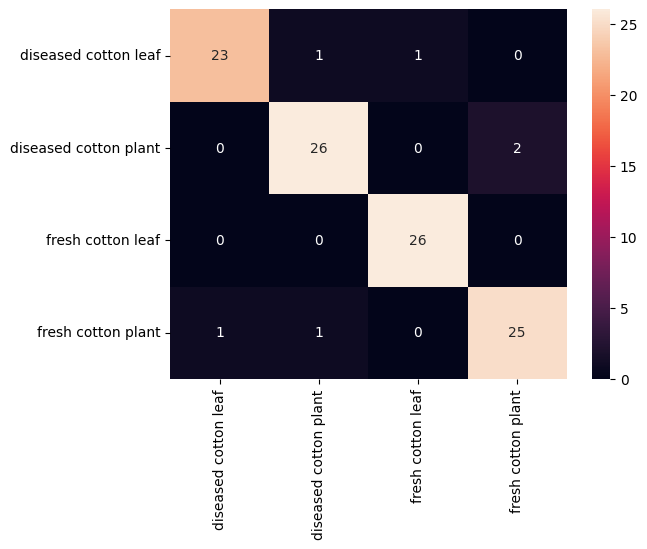


Class-wise:
diseased cotton leaf 0.9583333333333334 0.92 0.9387755102040817 25
diseased cotton plant 0.9285714285714286 0.9285714285714286 0.9285714285714286 28
fresh cotton leaf 0.9629629629629629 1.0 0.9811320754716981 26
fresh cotton plant 0.9259259259259259 0.9259259259259259 0.9259259259259259 27


In [1]:
# =========================
# CUSTOM CNN - FULL PIPELINE
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# ---- CONFIG ----
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 10
NUM_CLASSES = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- DATA ----
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=transform)
val_data   = datasets.ImageFolder(f"{DATA_PATH}/val", transform=transform)
test_data  = datasets.ImageFolder(f"{DATA_PATH}/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE)

class_names = train_data.classes

# ---- MODEL ----
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Linear(256,NUM_CLASSES)
        )
    def forward(self,x):
        return self.fc(self.conv(x))

model = CustomCNN().to(device)

# ---- TRAIN ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

best_val_acc = 0

def evaluate(model, loader):
    model.eval()
    preds, labels, probs = [], [], []

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)

            prob = torch.softmax(out, dim=1)
            pred = out.argmax(1)

            preds.extend(pred.cpu().numpy())
            labels.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    acc = (np.array(preds)==np.array(labels)).mean()*100
    f1 = f1_score(labels, preds, average="macro")

    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    auc = roc_auc_score(labels_bin, probs, average="macro", multi_class="ovr")

    return acc, f1, auc, preds, labels

for epoch in range(EPOCHS):
    model.train()
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    val_acc, val_f1, val_auc, _, _ = evaluate(model,val_loader)
    best_val_acc = max(best_val_acc, val_acc)

    print(f"Epoch {epoch+1}: ValAcc={val_acc:.2f} F1={val_f1:.3f} AUC={val_auc:.3f}")

# ---- TEST ----
test_acc, test_f1, test_auc, preds, labels = evaluate(model,test_loader)

print("\nFinal Results:")
print(test_acc, test_f1, test_auc, best_val_acc)

# ---- CONFUSION MATRIX ----
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names)
plt.show()

# ---- CLASSWISE ----
p,r,f,s = precision_recall_fscore_support(labels,preds,average=None)
print("\nClass-wise:")
for i in range(len(class_names)):
    print(class_names[i], p[i], r[i], f[i], s[i])

# ---- SAVE ----
torch.save(model.state_dict(), "/kaggle/working/custom_cnn.pth")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: ValAcc=81.42 F1=0.803 AUC=0.982
Epoch 2: ValAcc=89.72 F1=0.891 AUC=0.990
Epoch 3: ValAcc=92.89 F1=0.923 AUC=0.994
Epoch 4: ValAcc=92.09 F1=0.913 AUC=0.994
Epoch 5: ValAcc=91.70 F1=0.905 AUC=0.994

Final Results:
90.56603773584906 0.9047113741262678 0.9923120623028323 92.88537549407114


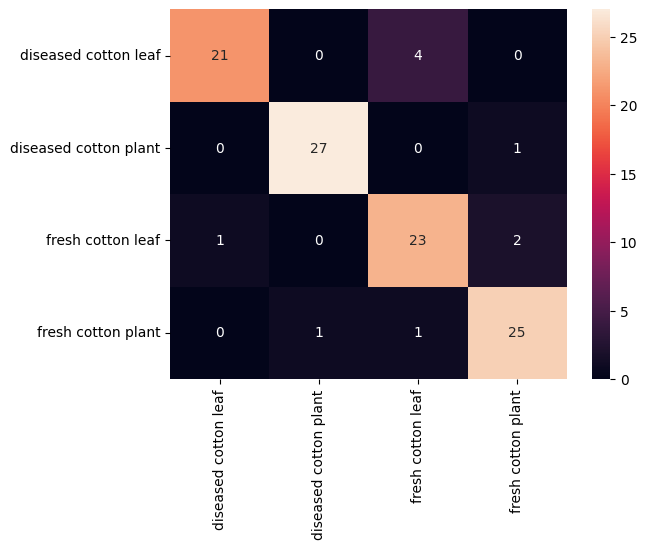


Class-wise:
diseased cotton leaf 0.9545454545454546 0.84 0.8936170212765957 25
diseased cotton plant 0.9642857142857143 0.9642857142857143 0.9642857142857143 28
fresh cotton leaf 0.8214285714285714 0.8846153846153846 0.8518518518518519 26
fresh cotton plant 0.8928571428571429 0.9259259259259259 0.9090909090909091 27


In [13]:
# =========================
# INCEPTION V3 - FULL PIPELINE
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---- CONFIG ----
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"
IMG_SIZE = 299
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- DATA ----
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=transform)
val_data   = datasets.ImageFolder(f"{DATA_PATH}/val", transform=transform)
test_data  = datasets.ImageFolder(f"{DATA_PATH}/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE)

class_names = train_data.classes

# ---- MODEL ----
model = models.inception_v3(pretrained=True)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.aux_logits = False
model = model.to(device)

# ---- TRAIN ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

best_val_acc = 0

def evaluate(model, loader):
    model.eval()
    preds, labels, probs = [], [], []

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)

            prob = torch.softmax(out, dim=1)
            pred = out.argmax(1)

            preds.extend(pred.cpu().numpy())
            labels.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    acc = (np.array(preds)==np.array(labels)).mean()*100
    f1 = f1_score(labels, preds, average="macro")

    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    auc = roc_auc_score(labels_bin, probs, average="macro", multi_class="ovr")

    return acc, f1, auc, preds, labels

for epoch in range(EPOCHS):
    model.train()

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()

        out = model(x)

        # 🔥 FIX: handle tuple output
        if isinstance(out, tuple):
            out = out[0]

        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

    val_acc, val_f1, val_auc, _, _ = evaluate(model,val_loader)
    best_val_acc = max(best_val_acc, val_acc)

    print(f"Epoch {epoch+1}: ValAcc={val_acc:.2f} F1={val_f1:.3f} AUC={val_auc:.3f}")
# ---- TEST ----
test_acc, test_f1, test_auc, preds, labels = evaluate(model,test_loader)

print("\nFinal Results:")
print(test_acc, test_f1, test_auc, best_val_acc)

# ---- CONFUSION MATRIX ----
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names)
plt.show()

# ---- CLASSWISE ----
p,r,f,s = precision_recall_fscore_support(labels,preds,average=None)
print("\nClass-wise:")
for i in range(len(class_names)):
    print(class_names[i], p[i], r[i], f[i], s[i])

# ---- SAVE ----
torch.save(model.state_dict(), "/kaggle/working/inception_v3.pth")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


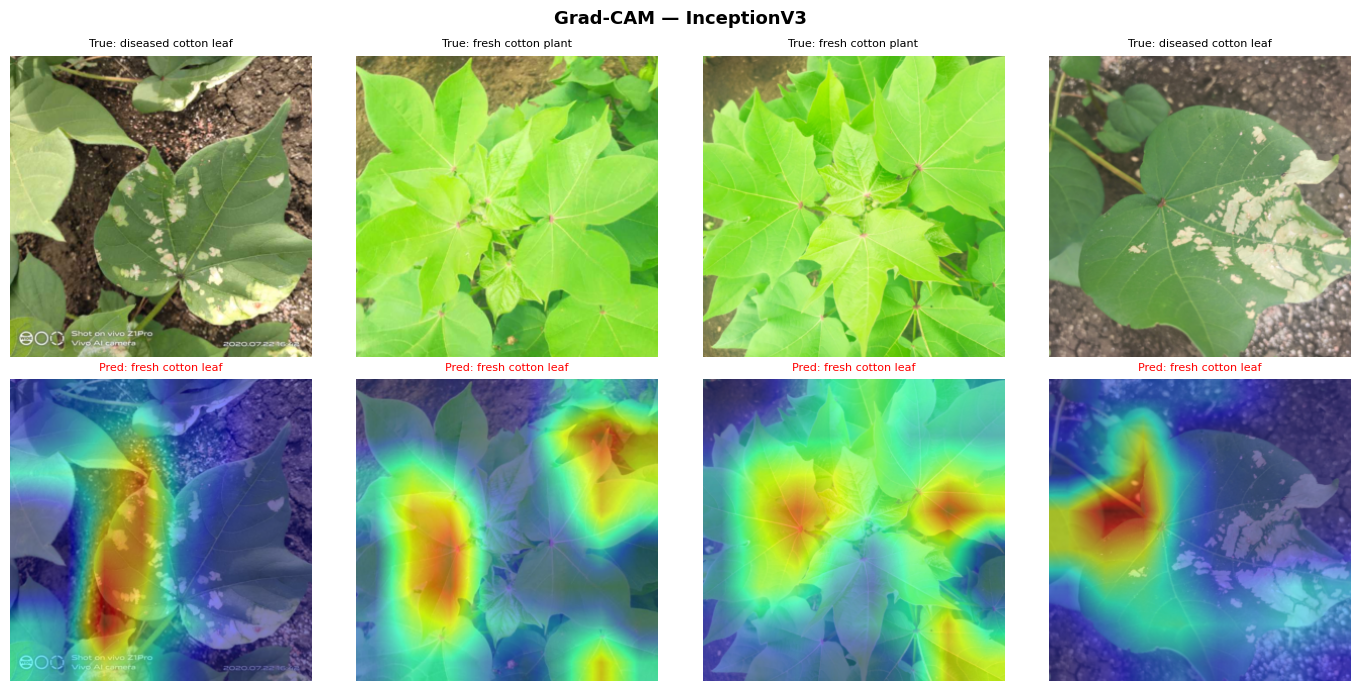

Saved → /kaggle/working/gradcam_InceptionV3.png


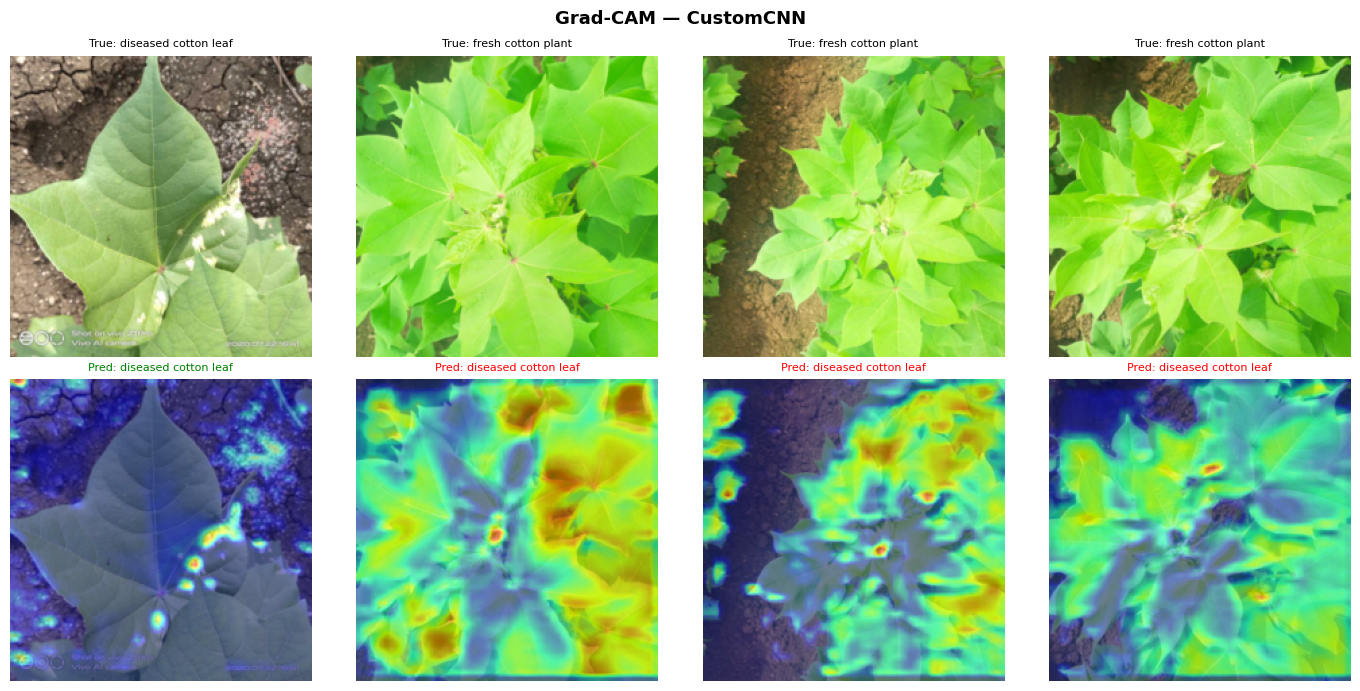

Saved → /kaggle/working/gradcam_CustomCNN.png


In [16]:
# =========================
# GRAD-CAM - INCEPTION + CUSTOM CNN
# =========================
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# ── Constants matching YOUR code ──────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MEAN   = [0.485, 0.456, 0.406]
STD    = [0.229, 0.224, 0.225]

# ── Reload test loaders with correct IMG_SIZE per model ───────────────
DATA_PATH = "/kaggle/input/datasets/janmejaybhoi/cotton-disease-dataset/Cotton Disease"

test_transform_299 = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_data_299 = datasets.ImageFolder(f"{DATA_PATH}/test", transform=test_transform_299)
test_data_224 = datasets.ImageFolder(f"{DATA_PATH}/test", transform=test_transform_224)

test_loader_299 = DataLoader(test_data_299, batch_size=8, shuffle=True)
test_loader_224 = DataLoader(test_data_224, batch_size=8, shuffle=True)

CLASS_NAMES = test_data_299.classes

# =========================
# GRAD-CAM CLASS
# =========================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

    def generate(self, img_tensor):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        activations = []
        def forward_hook(module, input, output):
            activations.append(output)

        handle = self.target_layer.register_forward_hook(forward_hook)

        # Forward
        output = self.model(img_tensor)
        if isinstance(output, tuple):
            output = output[0]

        class_idx = output.argmax(dim=1).item()

        # Grad via autograd (avoids hook issues)
        grads = torch.autograd.grad(
            outputs=output[0, class_idx],
            inputs=activations[0],
            retain_graph=False
        )[0]

        acts = activations[0]
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1)
        cam = F.relu(cam).squeeze().detach().cpu().numpy()
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        handle.remove()
        return cam, class_idx


# =========================
# VISUALIZATION
# =========================
def show_gradcam(model, target_layer, loader, title):
    model = model.to(DEVICE)
    model.eval()
    gc = GradCAM(model, target_layer)

    inv_norm = transforms.Normalize(
        mean=[-m/s for m, s in zip(MEAN, STD)],
        std=[1/s for s in STD]
    )

    imgs, labels = next(iter(loader))
    n = 4
    fig, axes = plt.subplots(2, n, figsize=(3.5*n, 7))

    for i in range(n):
        img_t = imgs[i]
        cam, pred_idx = gc.generate(img_t)

        img_np = inv_norm(img_t).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
        h, w = img_np.shape[:2]

        cam_r = cv2.resize(cam, (w, h))
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = (0.5 * img_np + 0.5 * heatmap).clip(0, 1)

        axes[0, i].imshow(img_np)
        axes[0, i].set_title(f"True: {CLASS_NAMES[labels[i]]}", fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(overlay)
        axes[1, i].set_title(
            f"Pred: {CLASS_NAMES[pred_idx]}",
            fontsize=8,
            color="green" if pred_idx == labels[i].item() else "red"
        )
        axes[1, i].axis("off")

    plt.suptitle(f"Grad-CAM — {title}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_path = f"/kaggle/working/gradcam_{title}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_path}")


# =========================
# LOAD SAVED MODELS
# =========================

# ── Inception-V3 ──────────────────────────────────────────────────────
from torchvision import models
import torch.nn as nn

inception_model = models.inception_v3(pretrained=False)
inception_model.fc = nn.Linear(inception_model.fc.in_features, 4)
inception_model.aux_logits = False
inception_model.load_state_dict(torch.load("/kaggle/working/inception_v3.pth", map_location=DEVICE))
inception_model = inception_model.to(DEVICE)
inception_model.eval()

# ── Custom CNN ────────────────────────────────────────────────────────
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

custom_model = CustomCNN().to(DEVICE)
custom_model.load_state_dict(torch.load("/kaggle/working/custom_cnn.pth", map_location=DEVICE))
custom_model.eval()

# =========================
# RUN GRAD-CAM
# =========================

# Inception — Mixed_6e is stable, Mixed_7c also works
show_gradcam(
    inception_model,
    inception_model.Mixed_7c,   # last inception block
    test_loader_299,             # 299x299 loader
    "InceptionV3"
)

# Custom CNN — last Conv2d = conv[6] (Conv 64->128)
show_gradcam(
    custom_model,
    custom_model.conv[6],        # Conv2d(64, 128, ...)
    test_loader_224,             # 224x224 loader
    "CustomCNN"
)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names, title="Model"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Confusion Matrix — {title}", fontsize=14, fontweight="bold")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.savefig(f"/kaggle/working/confusion_matrix_{title}.png", dpi=200)
    plt.show()

In [19]:
plot_confusion_matrix(y_true, y_pred, class_names, "InceptionV3")

NameError: name 'y_true' is not defined

In [22]:
# ---- GET PROBABILITIES FOR ROC (INCEPTION) ----
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)

        # handle tuple (inception safety)
        if isinstance(out, tuple):
            out = out[0]

        prob = torch.softmax(out, dim=1)

        all_probs.extend(prob.cpu().numpy())
        all_labels.extend(y.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

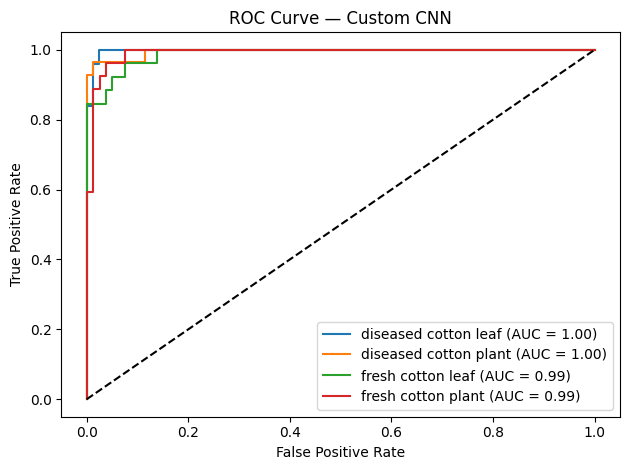

In [24]:
# ---- ROC CURVE ----
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# binarize labels
y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

plt.figure()

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # diagonal

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Custom CNN")
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("/kaggle/working/roc_custom_cnn.png", dpi=200)
plt.show()

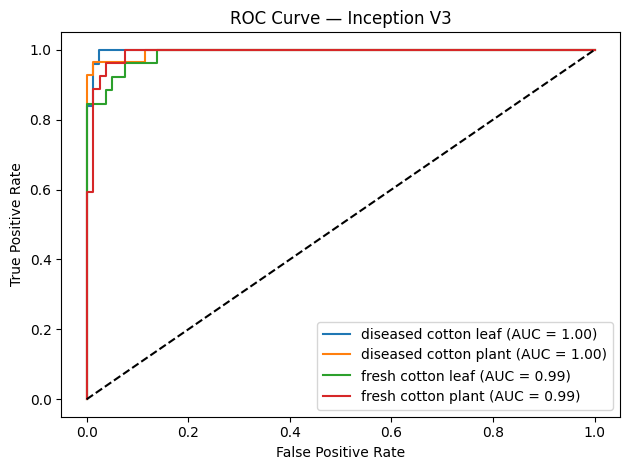

In [25]:
# ---- ROC CURVE (INCEPTION V3) ----
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

plt.figure()

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Inception V3")
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("/kaggle/working/roc_inception_v3.png", dpi=200)
plt.show()